## Ejercicio 1

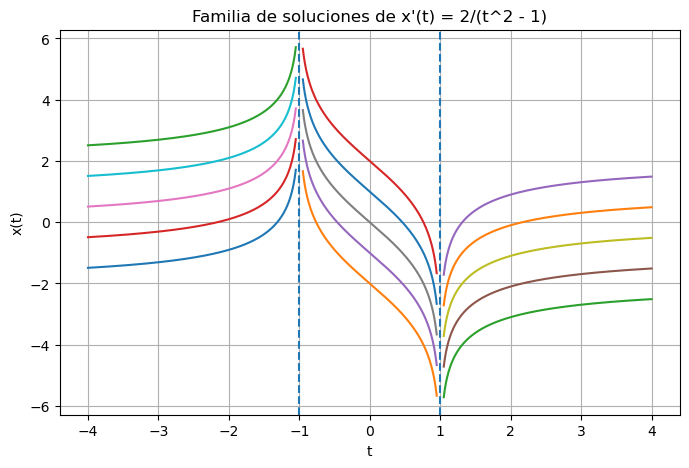

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Definir intervalos evitando las singularidades
t1 = np.linspace(-4, -1.05, 400)
t2 = np.linspace(-0.95, 0.95, 400)
t3 = np.linspace(1.05, 4, 400)

# Familia de constantes
C_values = [-2, -1, 0, 1, 2]

def x_solution(t, C):
    return np.log(np.abs((t - 1)/(t + 1))) + C

plt.figure(figsize=(8,5))

for C in C_values:
    plt.plot(t1, x_solution(t1, C))
    plt.plot(t2, x_solution(t2, C))
    plt.plot(t3, x_solution(t3, C))

# Líneas verticales donde hay singularidades
plt.axvline(-1, linestyle='--')
plt.axvline(1, linestyle='--')

plt.xlabel("t")
plt.ylabel("x(t)")
plt.title("Familia de soluciones de x'(t) = 2/(t^2 - 1)")
plt.grid()
plt.show()


## Ejercicio 2

- En $x(t)=\frac{t^2-1}{t^2-1}$ si teniamos $x(t)$ expicita.
- En $x^{\prime}(t)=\frac{3 x}{x^2-4}$ la solución queda implícita:

$$
\frac{x^2}{6}-\frac{4}{3} \ln |x|=t+C
$$

y no se puede despejar $x(t)$ con funciones elementales.

Elegimos ahoran muchos valores de $x$ (en intervalos separados para evitar $x=0, \pm 2$ ).

Para cada $C$, calculamos el $t$ correspondiente:

$$
t=\left(\frac{x^2}{6}-\frac{4}{3} \ln |x|\right)-C
$$


Y graficamos $(t, x)$ y recortamos a $t \in[-5,5]$

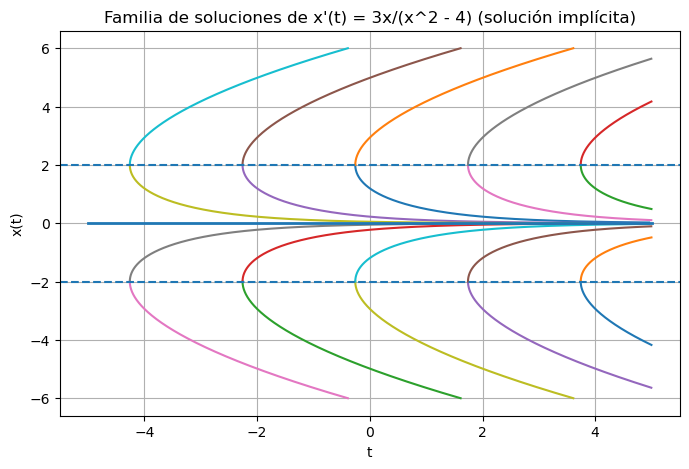

In [6]:
import numpy as np
import matplotlib.pyplot as plt

# Rango de tiempo que quieres ver
tmin, tmax = -5, 5

# Evitar puntos problemáticos
eps = 1e-3

# Intervalos en x (evitando x=0 y x=±2)
x1 = np.linspace(-6, -2-eps, 1200)     # (-∞,-2)
x2 = np.linspace(-2+eps, -eps, 1200)  # (-2,0)
x3 = np.linspace(eps, 2-eps, 1200)    # (0,2)
x4 = np.linspace(2+eps, 6, 1200)      # (2,∞)

# Familia de constantes
C_values = [-4, -2, 0, 2, 4]

def t_from_x(x, C):
    # De la solución implícita: x^2/6 - (4/3)ln|x| = t + C
    return x**2/6 - (4/3)*np.log(np.abs(x)) - C

plt.figure(figsize=(8,5))

for C in C_values:
    for xr in [x1, x2, x3, x4]:
        t = t_from_x(xr, C)

        # Recortar a t en [tmin, tmax]
        mask = (t >= tmin) & (t <= tmax)
        plt.plot(t[mask], xr[mask])

# Líneas de singularidad (en x = ±2)
plt.axhline(2, linestyle='--')
plt.axhline(-2, linestyle='--')

# Solución de equilibrio (especial): x(t)=0
plt.plot([tmin, tmax], [0, 0], linewidth=2)

plt.xlabel("t")
plt.ylabel("x(t)")
plt.title("Familia de soluciones de x'(t) = 3x/(x^2 - 4) (solución implícita)")
plt.grid()
plt.show()


## Métodos mas avanzados: Runge-Kutta de cuarto orden (RK4) 

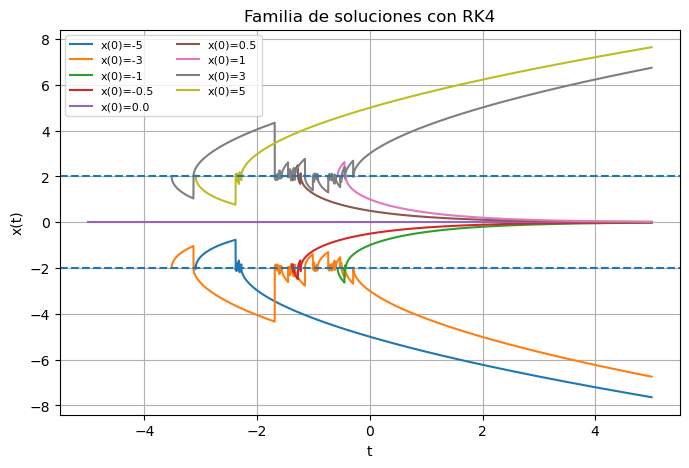

In [9]:
import numpy as np
import matplotlib.pyplot as plt

def f(x):
    return 3*x/(x**2 - 4)

def phi(x):
    return x**2/6 - (4/3)*np.log(np.abs(x))

def rk4_step(x, h):
    k1 = f(x)
    k2 = f(x + 0.5*h*k1)
    k3 = f(x + 0.5*h*k2)
    k4 = f(x + h*k3)
    return x + (h/6)*(k1 + 2*k2 + 2*k3 + k4)

def integrate_rk4_bidir(x0, tmin, tmax, h=1e-3, eps=1e-3):

 ##Integra hacia adelante y hacia atrás desde t=0, para mostrar la curva completa en [tmin, tmax],
    ## cortando si se acerca a x=±2.

    # Solución especial: equilibrio
    if x0 == 0.0:
        t = np.array([tmin, tmax])
        x = np.array([0.0, 0.0])
        return t, x

    # Evitar singularidades iniciales
    if abs(x0 - 2) < 1e-12 or abs(x0 + 2) < 1e-12:
        return np.array([]), np.array([])

    # --- integrar hacia adelante ---
    n_fwd = int(np.ceil((tmax - 0.0)/h))
    tf = np.empty(n_fwd+1)
    xf = np.empty(n_fwd+1)
    tf[0], xf[0] = 0.0, x0
    nf = 0
    for i in range(n_fwd):
        if abs(xf[i] - 2) < eps or abs(xf[i] + 2) < eps or abs(xf[i]**2 - 4) < eps:
            nf = i
            break
        tf[i+1] = tf[i] + h
        xf[i+1] = rk4_step(xf[i], h)
        nf = i+1

    tf = tf[:nf+1]
    xf = xf[:nf+1]

    # --- integrar hacia atrás ---
    n_bwd = int(np.ceil((0.0 - tmin)/h))
    tb = np.empty(n_bwd+1)
    xb = np.empty(n_bwd+1)
    tb[0], xb[0] = 0.0, x0
    nb = 0
    for i in range(n_bwd):
        if abs(xb[i] - 2) < eps or abs(xb[i] + 2) < eps or abs(xb[i]**2 - 4) < eps:
            nb = i
            break
        tb[i+1] = tb[i] - h
        xb[i+1] = rk4_step(xb[i], -h)   # paso negativo
        nb = i+1

    tb = tb[:nb+1]
    xb = xb[:nb+1]

    # Unir (quitando el punto repetido en t=0)
    t = np.concatenate([tb[::-1], tf[1:]])
    x = np.concatenate([xb[::-1], xf[1:]])

    return t, x

# Rango de tiempo 
tmin, tmax = -5, 5

# Valores iniciales (elige los que quieras)
x0_values = [-5, -3, -1, -0.5, 0.0, 0.5, 1, 3, 5]

plt.figure(figsize=(8,5))

for x0 in x0_values:
    t, x = integrate_rk4_bidir(x0, tmin, tmax, h=1e-3, eps=1e-3)
    if len(t) == 0:
        continue
    plt.plot(t, x, label=f"x(0)={x0}")

# Líneas de singularidad
plt.axhline(2, linestyle="--")
plt.axhline(-2, linestyle="--")

plt.xlabel("t")
plt.ylabel("x(t)")
plt.title("Familia de soluciones con RK4")
plt.grid(True)
plt.legend(ncol=2, fontsize=8)
plt.show()
